In [1]:
suppressPackageStartupMessages({
library(BSgenome.Hsapiens.UCSC.hg19)
library("GenomicRanges")
    })
options(repr.matrix.max.cols=1000, repr.matrix.max.rows=1000)

In [2]:
# load results of per-SV-signature experiemtents
# make comparisons
# gene expression at SV breakpoints and midpoints

In [3]:
intermediate_results_folder <- '/home/dg204/park_dglodzik/svig/'

In [4]:
plotHere <- TRUE

In [5]:
# load output run_sv_topography.R, focusing on tandem duplications in CCNE1-amp cases
data_fn <- paste0(intermediate_results_folder, "ccne1_dups/stats_ccne1_dups.RData")
load(data_fn)
mi <- round(length(resultList[['measure']])/2)

(resultList[['measure']]/resultList[['cvg']])[resultList[['minBin']]]
# replication time at SV midpoint
# resultList[['minBin']]: corresponds to midpoint poisition

numeric-Rle of length 1 with 1 run
  Lengths:       1
  Values : 59.7973

In [6]:
repliTime_list <- list()
# SV - vs repli-seq probe overlaps
# overlaps with SV margins
margin.left <- subset(resultList[['repliseq_o.df']], distGeneEndToMidpointScaled<(-1))
margin.right <- subset(resultList[['repliseq_o.df']], distGeneStartToMidpointScaled>(1))
# select overlaps with SV proper
within.SV <- subset(resultList[['repliseq_o.df']],distGeneEndToMidpointScaled>(-1) & distGeneStartToMidpointScaled<(1))
repliTime_list[['CCNE1margin']] = data.frame(genotype='CCNE1', type='margin', repliseq=c(margin.left$repli_measure, margin.right$repli_measure))
repliTime_list[['CCNE1within']] = data.frame(genotype='CCNE1', type='withinSV', repliseq=within.SV$repli_measure)

In [7]:
# midpoint replication time for CCNE1
v1 <- subset(resultList[['repliseq_o.df']], distGeneStartToMidpointScaledInt ==0)$repli_measure
mean(v1)

[1] 60.31391

In [8]:
# midpoint replication time for CDK12
data_fn <- paste0(intermediate_results_folder, "cdk12_dups/stats_cdk12_dups.RData")
load(data_fn)
mi <- round(length(resultList[['measure']])/2)
(resultList[['measure']]/resultList[['cvg']])[resultList[['minBin']]]

numeric-Rle of length 1 with 1 run
  Lengths:       1
  Values : 50.5725

In [9]:
# retrieve replication times for RS1 SVs in the CDK12-/-, separating shorter and longer ones
margin.left <- subset(subset(resultList[['repliseq_o.df']], rs.length<1e6), distGeneEndToMidpointScaled<(-1))
margin.right <- subset(subset(resultList[['repliseq_o.df']], rs.length<1e6), distGeneStartToMidpointScaled>(1))
within.SV <- subset(subset(resultList[['repliseq_o.df']], rs.length<1e6),distGeneEndToMidpointScaled>(-1) & distGeneStartToMidpointScaled<(1))
repliTime_list[['CDK12_shorter_margin']] = data.frame(genotype='CDK12_shorter', type='margin', repliseq=c(margin.left$repli_measure, margin.right$repli_measure))
repliTime_list[['CDK12_shorter_within']] = data.frame(genotype='CDK12_shorter', type='withinSV', repliseq=within.SV$repli_measure)

margin.left <- subset(subset(resultList[['repliseq_o.df']], rs.length>1e6), distGeneEndToMidpointScaled<(-1))
margin.right <- subset(subset(resultList[['repliseq_o.df']], rs.length>1e6), distGeneStartToMidpointScaled>(1))
within.SV <- subset(subset(resultList[['repliseq_o.df']], rs.length>1e6),distGeneEndToMidpointScaled>(-1) & distGeneStartToMidpointScaled<(1))
repliTime_list[['CDK12_longer_margin']] = data.frame(genotype='CDK12_longer', type='margin', repliseq=c(margin.left$repli_measure, margin.right$repli_measure))
repliTime_list[['CDK12_longer_within']] = data.frame(genotype='CDK12_longer', type='withinSV', repliseq=within.SV$repli_measure)

In [10]:
# all CDK12 SVs
margin.left <- subset(resultList[['repliseq_o.df']], distGeneEndToMidpointScaled<(-1))
margin.right <- subset(resultList[['repliseq_o.df']], distGeneStartToMidpointScaled>(1))
within.SV <- subset(resultList[['repliseq_o.df']],distGeneEndToMidpointScaled>(-1) & distGeneStartToMidpointScaled<(1))

In [11]:
# average replication time at CDK12 SV margins
mean(c(margin.left$repli_measure, 	margin.right$repli_measure))

[1] 46.52735

In [12]:
# average replication time within CDK12 SVs
mean(within.SV$repli_measure)

[1] 49.82475

In [13]:
# for CDK12, compare replication time within SVs and in the margins
wilcox.test(c(margin.left$repli_measure, 	margin.right$repli_measure), within.SV$repli_measure, paired = FALSE)


	Wilcoxon rank sum test with continuity correction

data:  c(margin.left$repli_measure, margin.right$repli_measure) and within.SV$repli_measure
W = 2.3149e+12, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


In [14]:
# midpoint replication time for CDK12
v2 <- subset(resultList[['repliseq_o.df']], distGeneStartToMidpointScaledInt ==0)$repli_measure
mean(v2)

[1] 51.40932

In [15]:
# comparing midpoint replication time between CCNE1 and CDK12, there are two vectors, each with repliseq probes
wilcox.test(v1, v2, paired = FALSE)


	Wilcoxon rank sum test with continuity correction

data:  v1 and v2
W = 34428376, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


In [16]:
# midpoint replication time for CDK12, R1
data_fn <- paste0(intermediate_results_folder, "cdk12_R1_dups/stats_cdk12_R1_dups.RData")

load(data_fn)
mi <- round(length(resultList[['measure']])/2)
(resultList[['measure']]/resultList[['cvg']])[resultList[['minBin']]]

numeric-Rle of length 1 with 1 run
  Lengths:      1
  Values : 52.381

In [17]:
# midpoint replication time for CDK12 R1
v3 <- subset(resultList[['repliseq_o.df']], distGeneStartToMidpointScaledInt ==0)$repli_measure
mean(v3)

[1] 53.52201

In [18]:
# comparing midpoint replication time between CCNE1 and CDK12 R1, there are two vectors, each with repliseq probes
wilcox.test(v1, v3, paired = FALSE)


	Wilcoxon rank sum test with continuity correction

data:  v1 and v3
W = 11079100, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


In [19]:
# gene expression
# retrieving SV vs gene expression overlaps

# CCNE1
data_fn <- paste0(intermediate_results_folder, "ccne1_dups/stats_ccne1_dups.RData")
load(data_fn)
# genes overlapping with lower SV breakpoint
v1 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
# genes overlapping with higher SV breakpoint
v2 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
# genes overlapping with SV midpoint
v3 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
# low expressed genes: lower SV breakpoint
v4 <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
# low expressed genes: higher SV breakpoint
v5 <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))

#  load results on randomly permuted SVs, for comparison
data_fn <- paste0(intermediate_results_folder,"ccne1_dups_shuffledSimple_shuffle_simple/stats_ccne1_dups_shuffledSimple_shuffle_simple.RData")
load(data_fn)
v1_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v2_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
v3_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))

# compare genes at observed breakpoints and observed midpoints, to equivalent results from shuffled SVs
# this comparison includes highly expressed genes
m <- matrix(c(nrow(v1) + nrow(v2), 
              nrow(v3), 
              nrow(v1_shuffle) + nrow(v2_shuffle), 
              nrow(v3_shuffle)), nrow=2, ncol=2, byrow=TRUE)
fisher.test(m)

print(paste(length(unique(rbind(v1,v2,v4,v5)$queryHits)), 'SVs overlap with at least one gene out of', length(resultList[['segments.gr']])))


	Fisher's Exact Test for Count Data

data:  m
p-value = 0.004958
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.060255 1.409249
sample estimates:
odds ratio 
  1.222231 


[1] "1886 SVs overlap with at least one gene out of 2464"


In [20]:
1886/2468

[1] 0.7641815

In [21]:
# same CCNE1 comparison, breakpoints vs midpoints, observed vs simulated
# unlike above, this includes low-expressed genes

data_fn <- paste0(intermediate_results_folder, "ccne1_dups/stats_ccne1_dups.RData")
load(data_fn)
v1 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v2 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
v3 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
v4 <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v5 <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
v6 <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
data_fn <- "/home/dg204/park_dglodzik/svig/ccne1_dups_shuffledSimple_shuffle_simple/stats_ccne1_dups_shuffledSimple_shuffle_simple.RData"
load(data_fn)
v1_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v2_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
v3_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
v4_shuffle <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v5_shuffle <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
v6_shuffle <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
m4 <- matrix(c(nrow(v1) + nrow(v2)+nrow(v4) + nrow(v5), nrow(v3)+nrow(v6), nrow(v1_shuffle) + nrow(v2_shuffle)+nrow(v4_shuffle) + nrow(v5_shuffle), nrow(v3_shuffle)+nrow(v6_shuffle)), nrow=2, ncol=2, byrow=TRUE)
fisher.test(m4)


	Fisher's Exact Test for Count Data

data:  m4
p-value = 2.248e-07
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.17965 1.44642
sample estimates:
odds ratio 
  1.306208 


In [22]:
# genes overlapping SVs in CDK12 cancers
# only consider the highly expressed genes
# compare to the simulated SVs

data_fn <- paste0(intermediate_results_folder,"/cdk12_dups/stats_cdk12_dups.RData")
load(data_fn)
v1 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v2 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
v3 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
v4 <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v5 <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))

data_fn <-  paste0(intermediate_results_folder,"cdk12_dups_shuffledSimple_shuffle_simple/stats_cdk12_dups_shuffledSimple_shuffle_simple.RData")
load(data_fn)
v1_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v2_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
v3_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))

m2 <- matrix(c(nrow(v1) + nrow(v2), nrow(v3), nrow(v1_shuffle) + nrow(v2_shuffle), nrow(v3_shuffle)), nrow=2, ncol=2, byrow=TRUE)

fisher.test(m2)

print(paste(length(unique(rbind(v1,v2, v4, v5)$queryHits)), 'SVs overlap with at least one gene out of', length(resultList[['segments.gr']])))


	Fisher's Exact Test for Count Data

data:  m2
p-value = 0.8897
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.8442429 1.2233236
sample estimates:
odds ratio 
  1.016238 


[1] "951 SVs overlap with at least one gene out of 1442"


In [23]:
# proportion of SVs with transcription at either end
951/1449

[1] 0.6563147

In [24]:
# CDK12-focus comparison of genes at breakpoints vs midpoints
# compared against randomly sampled SVs
data_fn <-  paste0(intermediate_results_folder,"/cdk12_dups/stats_cdk12_dups.RData")
load(data_fn)
v1 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v2 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
v3 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
v4 <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v5 <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
v6 <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
data_fn <-  paste0(intermediate_results_folder,"/cdk12_dups_shuffledSimple_shuffle_simple/stats_cdk12_dups_shuffledSimple_shuffle_simple.RData")
load(data_fn)
v1_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v2_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
v3_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
v4_shuffle <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v5_shuffle <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
v6_shuffle <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
m4 <- matrix(c(nrow(v1) + nrow(v2)+nrow(v4) + nrow(v5), 
               nrow(v3)+nrow(v6), 
               nrow(v1_shuffle) + nrow(v2_shuffle)+nrow(v4_shuffle) + nrow(v5_shuffle), 
               nrow(v3_shuffle)+nrow(v6_shuffle)), nrow=2, ncol=2, byrow=TRUE)
fisher.test(m4)


	Fisher's Exact Test for Count Data

data:  m4
p-value = 0.4698
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.8290908 1.0913986
sample estimates:
odds ratio 
 0.9512974 


In [25]:
# CDK12-focused comparison
# only the longer SVs
# only the highly expressed genes

data_fn <-  paste0(intermediate_results_folder,"cdk12_dups_longer/stats_cdk12_dups_longer.RData")
load(data_fn)
v1 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v2 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
v3 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
data_fn <-  paste0(intermediate_results_folder,"/cdk12_dups_longer_shuffle_flip/stats_cdk12_dups_longer_shuffle_flip.RData")
load(data_fn)
v1_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v2_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
v3_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))

m3 <- matrix(c(nrow(v1) + nrow(v2), nrow(v3), 
               nrow(v1_shuffle) + nrow(v2_shuffle), nrow(v3_shuffle)), nrow=2, ncol=2, byrow=TRUE)

fisher.test(m3)


	Fisher's Exact Test for Count Data

data:  m3
p-value = 0.5259
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.8085157 1.5435909
sample estimates:
odds ratio 
   1.11677 


In [28]:
# all RS1 SVs
# genes at SV breakpoints compared to the midpointss
# comparison includes low expressed genes
data_fn <-  paste0(intermediate_results_folder,"/RS1/stats_RS1.RData")
load(data_fn)
v1 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v2 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
v3 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
v4 <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v5 <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
v6 <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
data_fn <-  paste0(intermediate_results_folder,"RS1_shuffle_simple/stats_RS1_shuffle_simple.RData")
load(data_fn)
v1_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v2_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
v3_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
v4_shuffle <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
v5_shuffle <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
v6_shuffle <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
m4 <- matrix(c(nrow(v1) + nrow(v2)+nrow(v4) + nrow(v5), nrow(v3)+nrow(v6), nrow(v1_shuffle) + nrow(v2_shuffle)+nrow(v4_shuffle) + nrow(v5_shuffle), nrow(v3_shuffle)+nrow(v6_shuffle)), nrow=2, ncol=2, byrow=TRUE)
fisher.test(m4)


	Fisher's Exact Test for Count Data

data:  m4
p-value = 7.192e-10
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.078061 1.156866
sample estimates:
odds ratio 
  1.116765 


In [29]:
# all RS14- attributed SVs
# replication timing in SVs compared to SV margins
data_fn <-  paste0(intermediate_results_folder,"/RS14/stats_RS14.RData")
load(data_fn)
margin.left <- subset(resultList[['repliseq_o.df']], distGeneEndToMidpointScaled<(-1))
margin.right <- subset(resultList[['repliseq_o.df']], distGeneStartToMidpointScaled>(1))
within.SV <- subset(resultList[['repliseq_o.df']],distGeneEndToMidpointScaled>(-1) & distGeneStartToMidpointScaled<(1))
wilcox.test(c(margin.left$repli_measure, 	within.SV$repli_measure), within.SV$repli_measure, paired = FALSE)


	Wilcoxon rank sum test with continuity correction

data:  c(margin.left$repli_measure, within.SV$repli_measure) and within.SV$repli_measure
W = 1.6252e+13, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


In [30]:
# replication timing in margins to compared to SVs
data_fn <-  paste0(intermediate_results_folder,"/RS1/stats_RS1.RData")
load(data_fn)
margin.left <- subset(resultList[['repliseq_o.df']], distGeneEndToMidpointScaled<(-1))
margin.right <- subset(resultList[['repliseq_o.df']], distGeneStartToMidpointScaled>(1))
within.SV <- subset(resultList[['repliseq_o.df']],distGeneEndToMidpointScaled>(-1) & distGeneStartToMidpointScaled<(1))
wilcox.test(c(margin.left$repli_measure, 	within.SV$repli_measure), within.SV$repli_measure, paired = FALSE)


	Wilcoxon rank sum test with continuity correction

data:  c(margin.left$repli_measure, within.SV$repli_measure) and within.SV$repli_measure
W = 5.2701e+13, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


In [31]:
# function that compares gene positioning wrt. SVs for two experiments
# where 1 is likely real, and the other one likely shuffled
processGeneStats <- function(data_fn, data_shuffled_fn) {

    load(data_fn)
    v1 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
    v2 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
    v3 <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
    v4 <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
    v5 <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
    v6 <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))

    print(paste(length(unique(rbind(v1,v2,v4,v5)$queryHits)), 'SVs overlap with at least one gene out of', length(resultList[['segments.gr']])))
    print(length(unique(rbind(v1,v2,v4,v5)$queryHits))/length(resultList[['segments.gr']]))

    allSVs <- length(resultList[['segments.gr']])
    
    load(data_shuffled_fn)
    v1_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
    v2_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
    v3_shuffle <- subset(resultList[['expression_profile_high']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
    v4_shuffle <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (-0.5) & distGeneEndToMidpointScaled > (-0.5)) )
    v5_shuffle <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < (0.5) & distGeneEndToMidpointScaled > (0.5)))
    v6_shuffle <- subset(resultList[['expression_profile_low']][['o.df']], (distGeneStartToMidpointScaled < 0 & distGeneEndToMidpointScaled > 0))
    m4 <- matrix(c(nrow(v1) + nrow(v2)+nrow(v4) + nrow(v5), nrow(v3)+nrow(v6), nrow(v1_shuffle) + nrow(v2_shuffle)+nrow(v4_shuffle) + nrow(v5_shuffle), nrow(v3_shuffle)+nrow(v6_shuffle)), nrow=2, ncol=2, byrow=TRUE)
    ft <- fisher.test(m4)
    print(ft)

    return(data.frame(svs_at_genes=length(unique(rbind(v1,v2,v4,v5)$queryHits))/allSVs,
                     genes_bps_midpoints_estimate=ft$estimate,
                      genes_bps_midpoints_conf_int_lower=ft$conf.int[1],
                      genes_bps_midpoints_conf_int_lower=ft$conf.int[2],
                     genes_bps_midpoints_P=ft$p.value                      
                     ))

}

In [32]:
resultList <- list()

In [33]:
data_fn <-  paste0(intermediate_results_folder,"ccne1_dups/stats_ccne1_dups.RData")
data_shuffled_fn <-  paste0(intermediate_results_folder,"/ccne1_dups_shuffledSimple_shuffle_simple/stats_ccne1_dups_shuffledSimple_shuffle_simple.RData")

resultList[['ccne1_dups']] <- processGeneStats(data_fn, data_shuffled_fn)


[1] "1886 SVs overlap with at least one gene out of 2451"
[1] 0.7694818

	Fisher's Exact Test for Count Data

data:  m4
p-value = 2.248e-07
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.17965 1.44642
sample estimates:
odds ratio 
  1.306208 



In [34]:
data_fn <-  paste0(intermediate_results_folder,"cdk12_dups/stats_cdk12_dups.RData")
data_shuffled_fn <-  paste0(intermediate_results_folder,"cdk12_dups_longer_shuffle_flip/stats_cdk12_dups_longer_shuffle_flip.RData")

resultList[['cdk12_dups']] <- processGeneStats(data_fn, data_shuffled_fn)

[1] "951 SVs overlap with at least one gene out of 1441"
[1] 0.6599584

	Fisher's Exact Test for Count Data

data:  m4
p-value = 0.3338
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.904160 1.329207
sample estimates:
odds ratio 
  1.097111 



In [35]:
data_fn <-  paste0(intermediate_results_folder,"/RS1/stats_RS1.RData")
data_shuffled_fn <-  paste0(intermediate_results_folder,"RS1_shuffle_simple/stats_RS1_shuffle_simple.RData")

resultList[['RS1']] <- processGeneStats(data_fn, data_shuffled_fn)

[1] "13477 SVs overlap with at least one gene out of 19835"
[1] 0.6794555

	Fisher's Exact Test for Count Data

data:  m4
p-value = 7.192e-10
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 1.078061 1.156866
sample estimates:
odds ratio 
  1.116765 



In [36]:
result.df <- do.call(rbind, resultList)

In [37]:
result.df

,svs_at_genes,genes_bps_midpoints_estimate,genes_bps_midpoints_conf_int_lower,genes_bps_midpoints_conf_int_lower.1,genes_bps_midpoints_P
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ccne1_dups,0.7694818,1.306208,1.179650,1.446420,2.248215e-07
cdk12_dups,0.6599584,1.097111,0.904160,1.329207,3.338033e-01
RS1,0.6794555,1.116765,1.078061,1.156866,7.191828e-10


In [38]:
# 
summary.df <- read.csv("../data/processed/origin.enrichment.per.signature.sep19th.csv")
result.m.df <- merge(result.df, summary.df, by.x="row.names", by.y="exp.name")
result.m.df <- result.m.df[nrow(result.m.df):1, ]
result.m.df

,Row.names,svs_at_genes,genes_bps_midpoints_estimate,genes_bps_midpoints_conf_int_lower,genes_bps_midpoints_conf_int_lower.1,genes_bps_midpoints_P,originEnrichmentES,originEnrichmentP,minBin,repliseq_midpoint_bp1_wilcoxonP,repliseq_midpoint_bp1_mean_diff,repliseq_midpoint_bp2_wilcoxonP,repliseq_midpoint_bp2_mean_diff,repliseq_midpoint_both_bp2s_wilcoxonP,gene_strand_bp_P,gene_strand_bp_estimate,gene_strand_bp_lower,gene_strand_bp_higher,gene_strand_sv_P,gene_strand_sv_estimate,gene_strand_sv_lower,gene_strand_sv_higher,median_length,repeatOverlapBpProp,repeatOverlapCoincidence,repeatL1FisherEstimate,repeatL1FisherEstimate_lower,repeatL1FisherEstimate_higher,repeatL1FisherPvalue
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,RS1,0.6794555,1.116765,1.078061,1.156866,7.191828e-10,1.236798,0.000000e+00,446,0.090802610,0.2324096,0.013079990,0.3625576,0.015998927,6.954525e-01,0.9869287,0.9253226,1.0526696,0.01731571,0.9742525,0.9535168,0.9954387,135.802,0.5042904,0.2887892,1.602725,1.4590716,1.759032,3.367240e-22
2,cdk12_dups,0.6599584,1.097111,0.904160,1.329207,3.338033e-01,1.188904,4.160090e-98,352,0.115053283,1.0349238,0.035365906,1.3573376,0.033611780,9.452398e-01,1.0144787,0.7678473,1.3403603,0.68151425,1.0119428,0.9569527,1.0700590,329.836,0.5233004,0.2570850,1.192526,0.8486254,1.655963,3.076032e-01
1,ccne1_dups,0.7694818,1.306208,1.179650,1.446420,2.248215e-07,1.219716,1.285534e-218,352,0.006979713,1.0266571,0.005570835,1.1420231,0.001588613,3.518656e-05,0.6907200,0.5773887,0.8259334,0.07755300,0.9609053,0.9192683,1.0044595,272.901,0.4987151,0.2703704,1.539237,1.1487382,2.043712,3.479719e-03


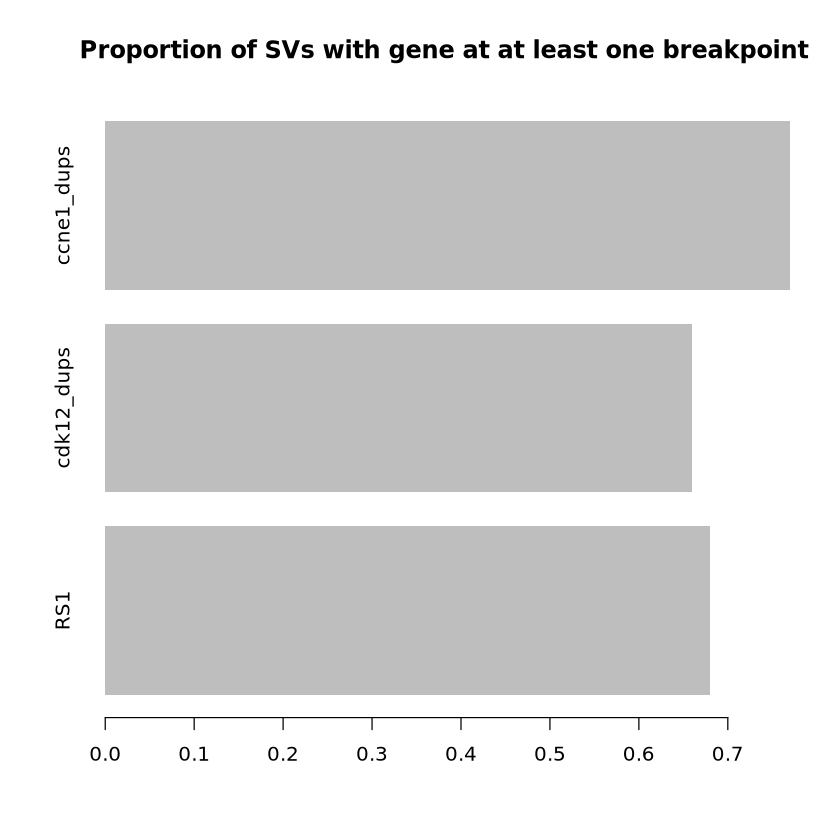

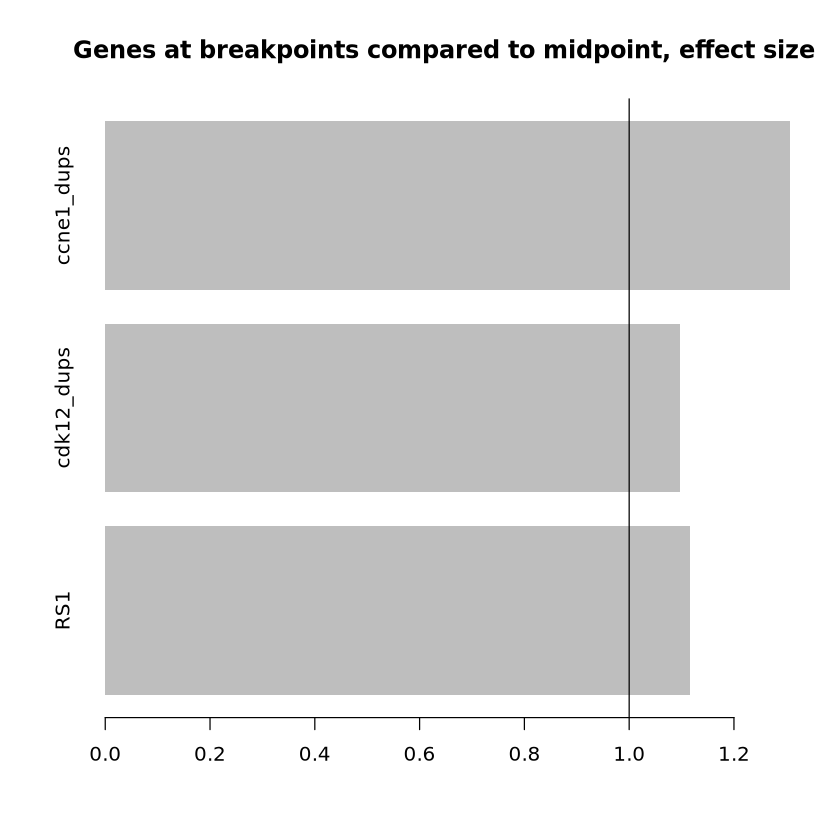

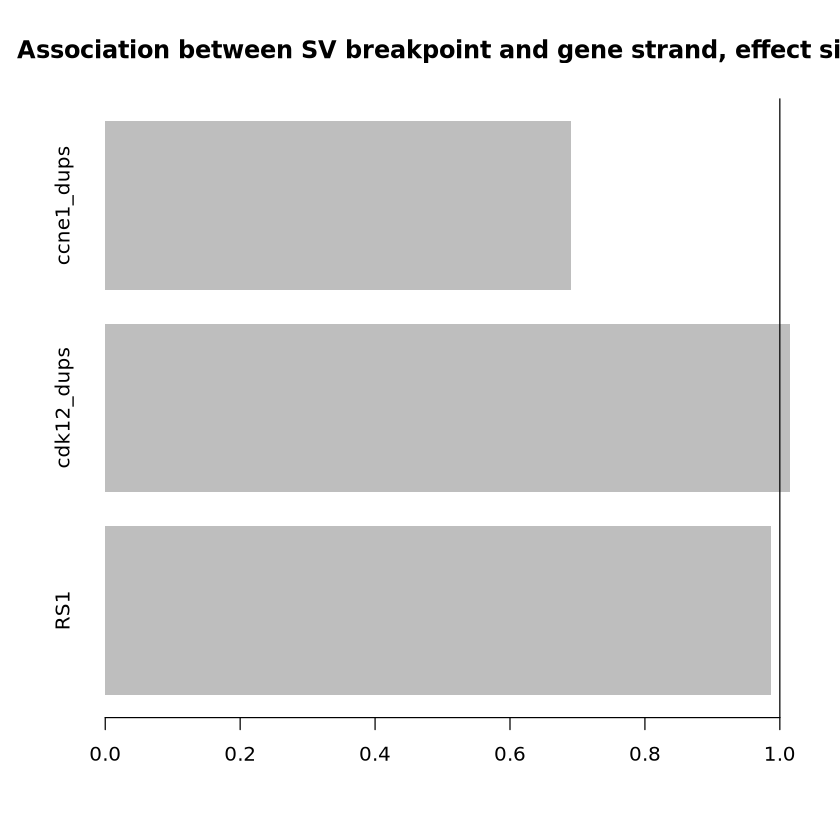

In [39]:
v <- result.m.df$svs_at_genes
names(v) <- result.m.df$Row.names
barplot(v, horiz=TRUE, border=NA, main='Proportion of SVs with gene at at least one breakpoint')

v <- result.m.df$genes_bps_midpoints_estimate
names(v) <- result.m.df$Row.names
barplot(v, horiz=TRUE, border=NA, main='Genes at breakpoints compared to midpoint, effect size')
abline(v=1)

v <- result.m.df$gene_strand_bp_estimate
names(v) <- result.m.df$Row.names
barplot(v, horiz=TRUE, border=NA, main='Association between SV breakpoint and gene strand, effect size')
abline(v=1)


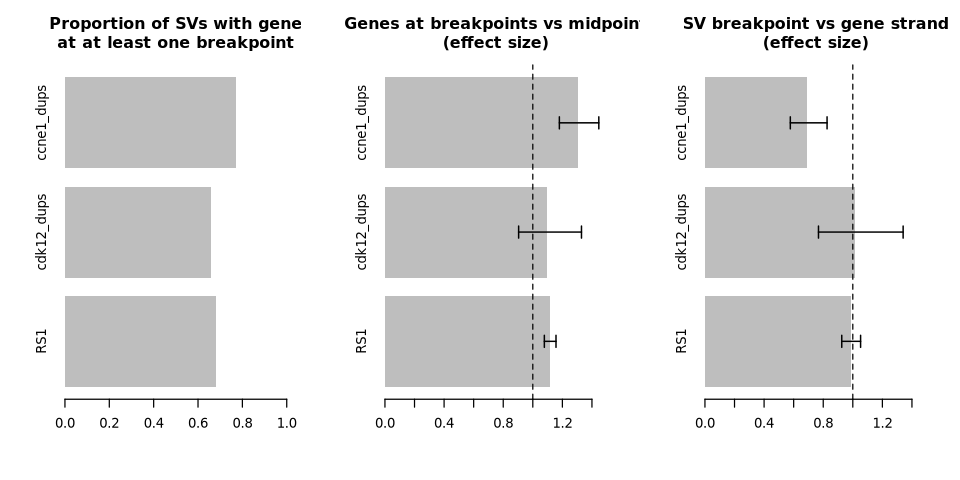

In [40]:
if (plotHere) {
    options(repr.plot.width=8, repr.plot.height=4)
} else {
    # Open PDF device
    pdf("../data/processed/paperPlots/transcription.pdf", width = 8, height = 4)
}

# Set up layout: 1 row, 3 columns
par(mfrow = c(1, 3))

# First plot
v <- result.m.df$svs_at_genes
names(v) <- result.m.df$Row.names
barplot(v, horiz = TRUE, border = NA,
        main = "Proportion of SVs with gene\nat at least one breakpoint", xlim=c(0,1))

# Second plot
v <- result.m.df$genes_bps_midpoints_estimate
names(v) <- result.m.df$Row.names
# Confidence intervals
ci_lower <- result.m.df$genes_bps_midpoints_conf_int_lower
ci_upper <- result.m.df$genes_bps_midpoints_conf_int_lower.1
# Create barplot
bp <- barplot(v, horiz = TRUE, border = NA,
              main = "Genes at breakpoints vs midpoint\n(effect size)", xlim=c(0,1.5))
# Add vertical reference line
abline(v = 1, lty = 2)
# Add error bars
arrows(x0 = ci_lower, y0 = bp, 
       x1 = ci_upper, y1 = bp,
       angle = 90, code = 3, length = 0.05, lwd = 1.2)

# Third plot
v <- result.m.df$gene_strand_bp_estimate
names(v) <- result.m.df$Row.names
bp <- barplot(v, horiz = TRUE, border = NA,
        main = "SV breakpoint vs gene strand\n(effect size)", xlim=c(0,1.5))
abline(v = 1, lty = 2)
# Add error bars
arrows(x0 = result.m.df$gene_strand_bp_lower, y0 = bp, 
       x1 = result.m.df$gene_strand_bp_higher, y1 = bp,
       angle = 90, code = 3, length = 0.05, lwd = 1.2)

if (!plotHere) {
    # Close PDF device
    dev.off()
}

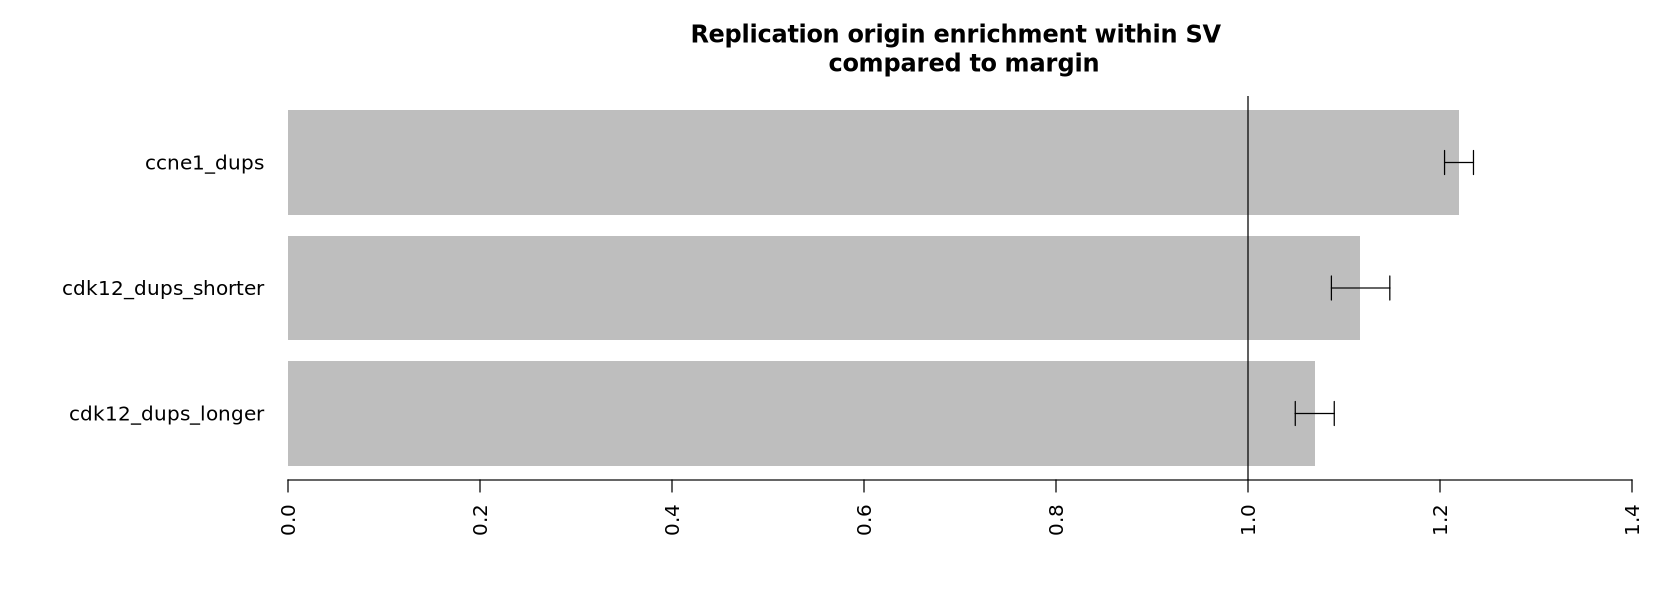

In [61]:
# load the topography summary
topography_df <- read.csv("../data/processed/origin.enrichment.per.signature.sep19th.csv")
# the newest version is missing originEnrichmentES_lower95
topography_df <- read.csv("../data/processed/origin.enrichment.per.signature.oct16th.csv")

op <- par(mar = c(5, 12, 4, 2))  # bottom, left, top, right


origin_es <- topography_df$originEnrichmentES
origin_es_low <- topography_df$originEnrichmentES_lower95
origin_es_high  <- topography_df$originEnrichmentES_higher

names(origin_es) <- topography_df$exp.name
origin_es <- origin_es[c('cdk12_dups_longer','cdk12_dups_shorter',  'ccne1_dups')]
names(origin_es_low) <- topography_df$exp.name
origin_es_low <- origin_es_low[c('cdk12_dups_longer','cdk12_dups_shorter',  'ccne1_dups')]
names(origin_es_high) <- topography_df$exp.name
origin_es_high <- origin_es_high[c('cdk12_dups_longer','cdk12_dups_shorter',  'ccne1_dups')]


bp <- barplot(origin_es, horiz=TRUE, border=NA, main='Replication origin enrichment within SV \n compared to margin', las=2, xlim=c(0,1.4))
abline(v=1)

arrows(x0 = origin_es_low, x1 = origin_es_high, y0 = bp, y1 = bp, angle = 90, code = 3, length = 0.1, col = "black", lwd = 1)


In [65]:
apobec_df <- read.csv("../data/processed/APOBEC_sig_channels_df.csv")
apobec_df_sel <- subset(apobec_df, exp.name %in% c('PCAWG_duplication_-1_10000000_null_CCNE1', 'PCAWG_duplication_-1_1000000_null_CDK12', 'PCAWG_duplication_1e+06_10000000_null_CDK12'))
v <- apobec_df_sel$odds.ratio.sv
v_low <- apobec_df_sel$polarity.effsize_low

v_high <- apobec_df_sel$polarity.effsize_high

In [66]:
v

[1] 3.140253 1.292215 2.062059

In [67]:
v_low

[1] 1.7666838 0.8735664 1.6921447

In [68]:
v_high

[1] 5.655587 1.914009 2.515086

In [69]:
label_map <- c(
  "PCAWG_duplication_-1_10000000_null_CCNE1" = "CCNE1",
  "PCAWG_duplication_-1_1000000_null_CDK12"  = "CDK12 shorter",
  "PCAWG_duplication_1e+06_10000000_null_CDK12" = "CDK12 longer"
)
names(v) <- label_map[apobec_df_sel$exp.name]
names(v_low) <- label_map[apobec_df_sel$exp.name]
names(v_high) <- label_map[apobec_df_sel$exp.name]
v <- v[c( "CDK12 longer",  "CDK12 shorter","CCNE1")]
v_low<- v_low[c( "CDK12 longer",  "CDK12 shorter","CCNE1")]
v_high <- v_high[c( "CDK12 longer",  "CDK12 shorter","CCNE1")]

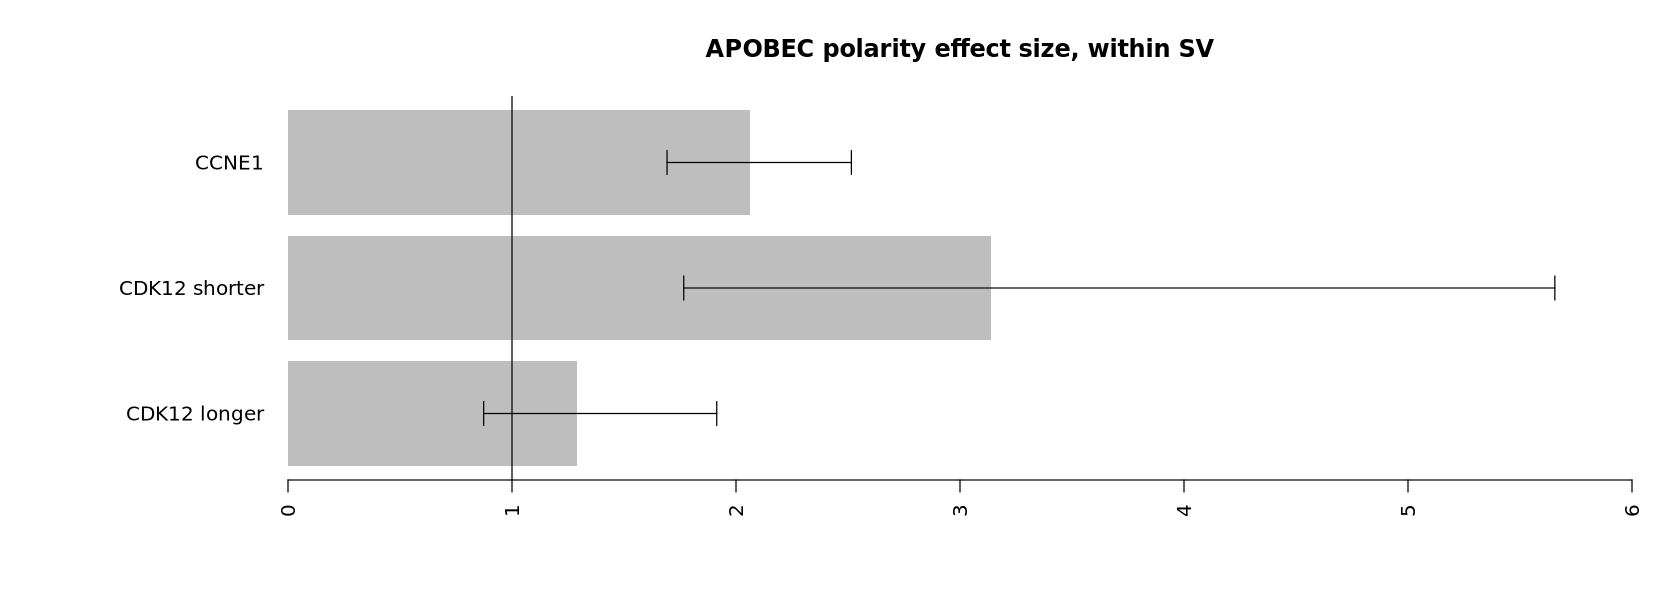

In [70]:
op <- par(mar = c(5, 12, 4, 2))  # bottom, left, top, right

bp <- barplot(v, horiz=TRUE, border=NA, main='APOBEC polarity effect size, within SV', las=2, xlim=c(0,6))
abline(v=1)
arrows(x0 = v_low, x1 = v_high, y0 = bp, y1 = bp, angle = 90, code = 3, length = 0.1, col = "black", lwd = 1)


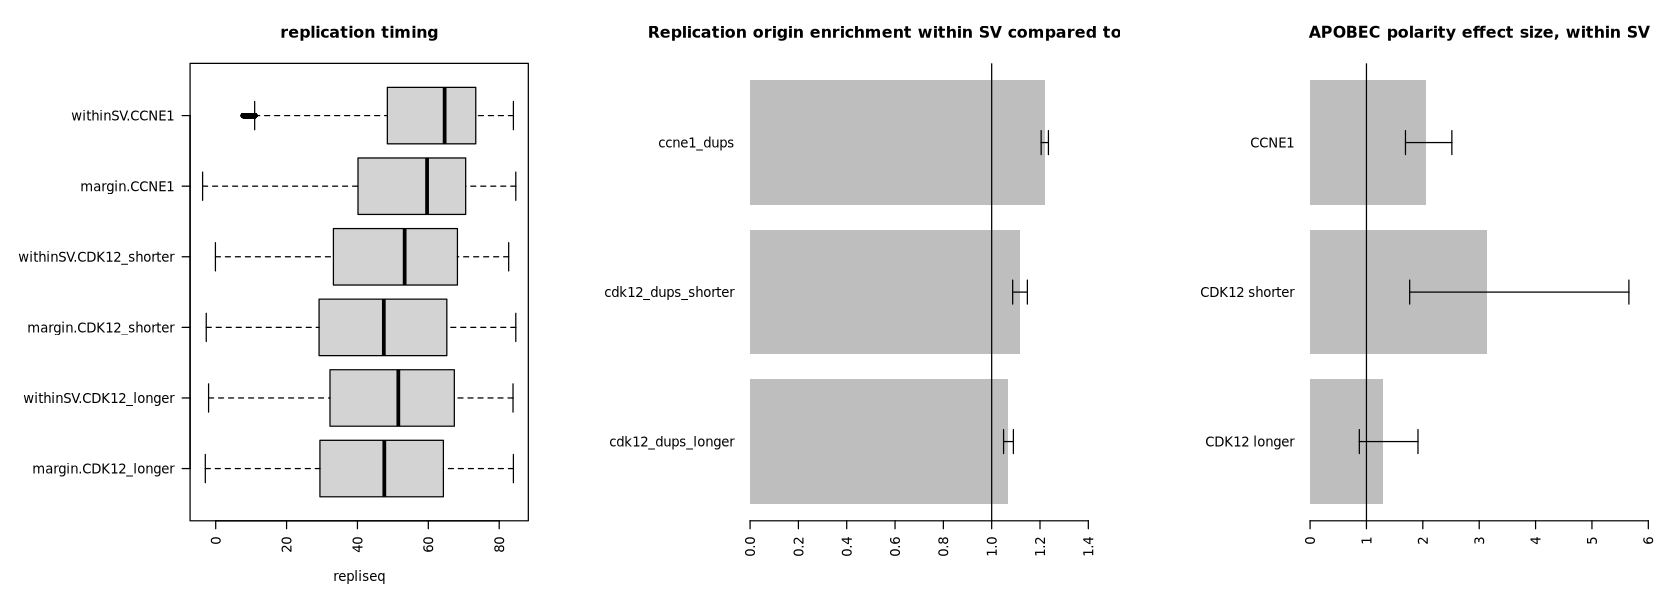

In [71]:
repliTime_df <- do.call('rbind', repliTime_list)
repliTime_df$genotype <- factor(repliTime_df$genotype, levels=c('CDK12_longer', 'CDK12_shorter', 'CCNE1'))


if (plotHere) {
    options(repr.plot.width=14, repr.plot.height=5)
} else {
    pdf("../data/processed/paperPlots/ccne1_cdk12.pdf", width = 14, height = 5)  # open PDF device
}

par(mfrow = c(1, 3))  # 1 row, 3 columns of plots




# Increase left margin before plotting
op <- par(mar = c(5, 12, 4, 2))  # bottom, left, top, right

boxplot(
  repliseq ~ type + genotype,
  data = repliTime_df,
  horizontal = TRUE,
  las = 2,   # vertical (perpendicular) y-axis labels
    ylab='',
    main='replication timing'
)

bp <- barplot(origin_es, horiz=TRUE, border=NA, main='Replication origin enrichment within SV compared to margin', las=2, xlim=c(0,1.4))
abline(v=1)
arrows(x0 = origin_es_low, x1 = origin_es_high, y0 = bp, y1 = bp, angle = 90, code = 3, length = 0.1, col = "black", lwd = 1)

# (Optional) restore old par settings afterward
par(op)

op <- par(mar = c(5, 12, 4, 2))  # bottom, left, top, right

bp <- barplot(v, horiz=TRUE, border=NA, main='APOBEC polarity effect size, within SV', las=2, xlim=c(0,6))
abline(v=1)
arrows(x0 = v_low, x1 = v_high, y0 = bp, y1 = bp, angle = 90, code = 3, length = 0.1, col = "black", lwd = 1)

# (Optional) restore old par settings afterward
par(op)

# (Optional) restore old par settings afterward
par(op)
if (!plotHere) {
    dev.off()  # close PDF
}


In [72]:
head(repliTime_df)

,genotype,type,repliseq
,<fct>,<chr>,<dbl>
CCNE1margin.1,CCNE1,margin,75.0596
CCNE1margin.2,CCNE1,margin,75.0855
CCNE1margin.3,CCNE1,margin,75.1113
CCNE1margin.4,CCNE1,margin,75.1368
CCNE1margin.5,CCNE1,margin,75.1620
CCNE1margin.6,CCNE1,margin,75.1871


In [73]:
table(repliTime_df$genotype)


 CDK12_longer CDK12_shorter         CCNE1 
      1949016       3033770       5279290 

In [74]:
v1 <- subset(repliTime_df, genotype=='CCNE1' & type=='withinSV')$repliseq
v2 <- subset(repliTime_df, genotype=='CCNE1' & type=='margin')$repliseq
wilcox.test(v1, v2)


	Wilcoxon rank sum test with continuity correction

data:  v1 and v2
W = 3.275e+12, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


In [75]:
v1 <- subset(repliTime_df, genotype=='CDK12_longer' & type=='withinSV')$repliseq
v2 <- subset(repliTime_df, genotype=='CDK12_longer' & type=='margin')$repliseq
wilcox.test(v1, v2)


	Wilcoxon rank sum test with continuity correction

data:  v1 and v2
W = 4.2645e+11, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


In [76]:
v1 <- subset(repliTime_df, genotype=='CDK12_shorter' & type=='withinSV')$repliseq
v2 <- subset(repliTime_df, genotype=='CDK12_shorter' & type=='margin')$repliseq
wilcox.test(v1, v2)


	Wilcoxon rank sum test with continuity correction

data:  v1 and v2
W = 1.033e+12, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0


In [77]:
v1 <- subset(repliTime_df, genotype=='CCNE1' & type=='withinSV')$repliseq
v2<- subset(repliTime_df, genotype=='CDK12_shorter' & type=='withinSV')$repliseq
wilcox.test(v1, v2)


	Wilcoxon rank sum test with continuity correction

data:  v1 and v2
W = 8.3173e+11, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0
